# Compare reservoir models
***

**Author:** *Chus Casado Rodríguez*<br>
**Date:** *10-06-2026*<br>

**Introduction:**<br>

This notebook analyses the results of the calibration of process-based reservoir routines on the ResOpsUS dataset.

The plot produced here will be used in the Appendix B.

**Ideas:**<br>

In [9]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

import pickle

from reservoirs_lshm import Config, read_attributes, read_timeseries
from reservoirs_lshm.utils.plots import swarmplot_components

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
#     "font.family": 'Arial',
    "font.size": 12,       # Default font size for text
#     "axes.titlesize": 16,  # Title font size
#     "axes.labelsize": 12,  # X and Y label font size
#     "xtick.labelsize": 13, # X tick font size
#     "ytick.labelsize": 12, # Y tick font size
#     "legend.fontsize": 12  # Legend font size
})

## Configuration

In [3]:
path = Path('/home/casadoj/Data/reservoirs')
cfg = Config(path / 'ResOpsUS/v2.1/results_before_GRanD_correction/mhm/mhm_storage.yml')

PATH_RESULTS = cfg.PATH_DEF.parent.parent
PATH_PLOTS = PATH_RESULTS / 'figures'
PATH_PLOTS.mkdir(parents=False, exist_ok=True)
print(f'Results will be saved in {PATH_PLOTS}')

models = {
    'lisflood': 'LISFLOOD',
    'camaflood': 'CaMa-Flood',
    'mhm': 'mHM',
    'starfit': 'Starfit'
}

runs = {
    'default': 'default',
    'OBJ-Q': 'calibration/univariate/outflow',
    'OBJ-V': 'calibration/univariate/storage',
    'OBJ-QV': 'calibration/bivariate'
}

Results will be saved in /home/casadoj/Data/reservoirs/ResOpsUS/v2.1/results_before_GRanD_correction/figures


## Data

### Reservoirs

In [4]:
# load reservoirs
reservoirs = gpd.read_file(cfg.PATH_DATA.parent / 'GIS' / 'reservoirs_677_3sec.shp').set_index('ID')
reservoirs.index.name = 'GRAND_ID'

print(f'{len(reservoirs)} reservoirs in the original ResOpsUS dataset')

677 reservoirs in the original ResOpsUS dataset


### Attributes

In [5]:
# list of reservoirs to be trained
reservoir_list = pd.read_csv(cfg.RESERVOIRS_FILE, header=None).squeeze().tolist()

# import all tables of attributes
attributes = read_attributes(cfg.PATH_DATA / 'attributes', reservoir_list)

# invert the one-hot encoder of main reservoir use
col_use = attributes.columns[attributes.columns.str.contains('MAIN_')]
col_use = [col for col in col_use if 'BASIN' not in col]
main_use = attributes[col_use].idxmax(axis=1)
attributes['MAIN_USE'] = main_use.replace({col: col.split('_')[-1] for col in col_use})
attributes.drop(col_use, axis=1, inplace=True)

# select items in reservoirs
reservoirs = reservoirs.loc[reservoirs.index.intersection(attributes.index)]

print(f'{len(attributes)} reservoirs in the attributes table')
print(f'{len(reservoirs)} reservoirs in the shape file')

164 reservoirs in the attributes table
164 reservoirs in the shape file


/tmp/ipykernel_51652/197166683.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  attributes['MAIN_USE'] = main_use.replace({col: col.split('_')[-1] for col in col_use})


### Time series

In [7]:
# training periods
with open(cfg.PERIODS_FILE, 'rb') as file:
    periods = pickle.load(file)
# periods = {str(ID): {f'{x}_dates': [date] for x, date in dct.items()} for ID, dct in periods.items()}

# read time series
inputs = [var for var in [cfg.INFLOW, cfg.PRECIPITATION, cfg.EVAPORATION, cfg.DEMAND] if var]
outputs = ['storage', 'outflow']
timeseries = read_timeseries(
    path=cfg.PATH_DATA / 'time_series' / 'csv',
    reservoirs=attributes.index,
    periods=periods,
    variables=inputs + outputs
)
print(f'{len(timeseries)} reservoirs in the time series')

  0%|          | 0/164 [00:00<?, ?it/s]

164 reservoirs in the time series


## Results

In [8]:
performance = []
for model in tqdm(models, desc='reservoir model'):

    pars_model = []
    perf_model = []
    for col, subpath in runs.items():

        path = PATH_RESULTS / model / subpath 

        # load performance
        try:
            perf_run = []
            for file in (path).glob('*_performance.csv'):
                grand_id = int(file.stem.split('_')[0])
                if grand_id not in attributes.index:
                    continue
                ds = xr.Dataset.from_dataframe(pd.read_csv(file, index_col='metric'))
                ds = ds.assign_coords(model=[model], run=[col], ID=[grand_id])
                perf_run.append(ds)
            perf_model.append(xr.concat(perf_run, dim='ID'))
        except Exception as e:
            print(f'Error while reading performance from model {model} and run {col}:\n{e}')  

    try:
        performance.append(xr.concat(perf_model, dim='run'))
    except:
        pass

performance = xr.concat(performance, dim='model')

# rename model 'hanazaki' as 'camaflood'
performance = performance.assign_coords(
    model=[m if 'hanazaki' not in m else 'camaflood' for m in performance.model.values]
)
performance = performance.assign_coords(model=[models[model] for model in performance.model.values])

reservoir model:   0%|          | 0/4 [00:00<?, ?it/s]

/tmp/ipykernel_51652/2560013549.py:20: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  perf_model.append(xr.concat(perf_run, dim='ID'))
/tmp/ipykernel_51652/2560013549.py:25: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  performance.append(xr.concat(perf_model, dim='run'))


Error while reading performance from model starfit and run default:
must supply at least one object to concatenate
Error while reading performance from model starfit and run OBJ-Q:
must supply at least one object to concatenate
Error while reading performance from model starfit and run OBJ-V:
must supply at least one object to concatenate


/tmp/ipykernel_51652/2560013549.py:29: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'run' ('run',) The recommendation is to set join explicitly for this case.
  performance = xr.concat(performance, dim='model')
/tmp/ipykernel_51652/2560013549.py:29: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'ID' ('ID',) The recommendation is to set join explicitly for this case.
  performance = xr.concat(performance, dim='model')
/tmp/ipykernel_51652/2560013549.py:29: FutureWarning: In a future version of xarray the default 

## Appendix B: KGE' components

In [ ]:
ds = performance[['outflow', 'storage']].sel(
    metric=['alpha', 'beta', 'rho'], 
    run=['default', 'OBJ-Q', 'OBJ-V', 'OBJ-QV']
)

### Compare models

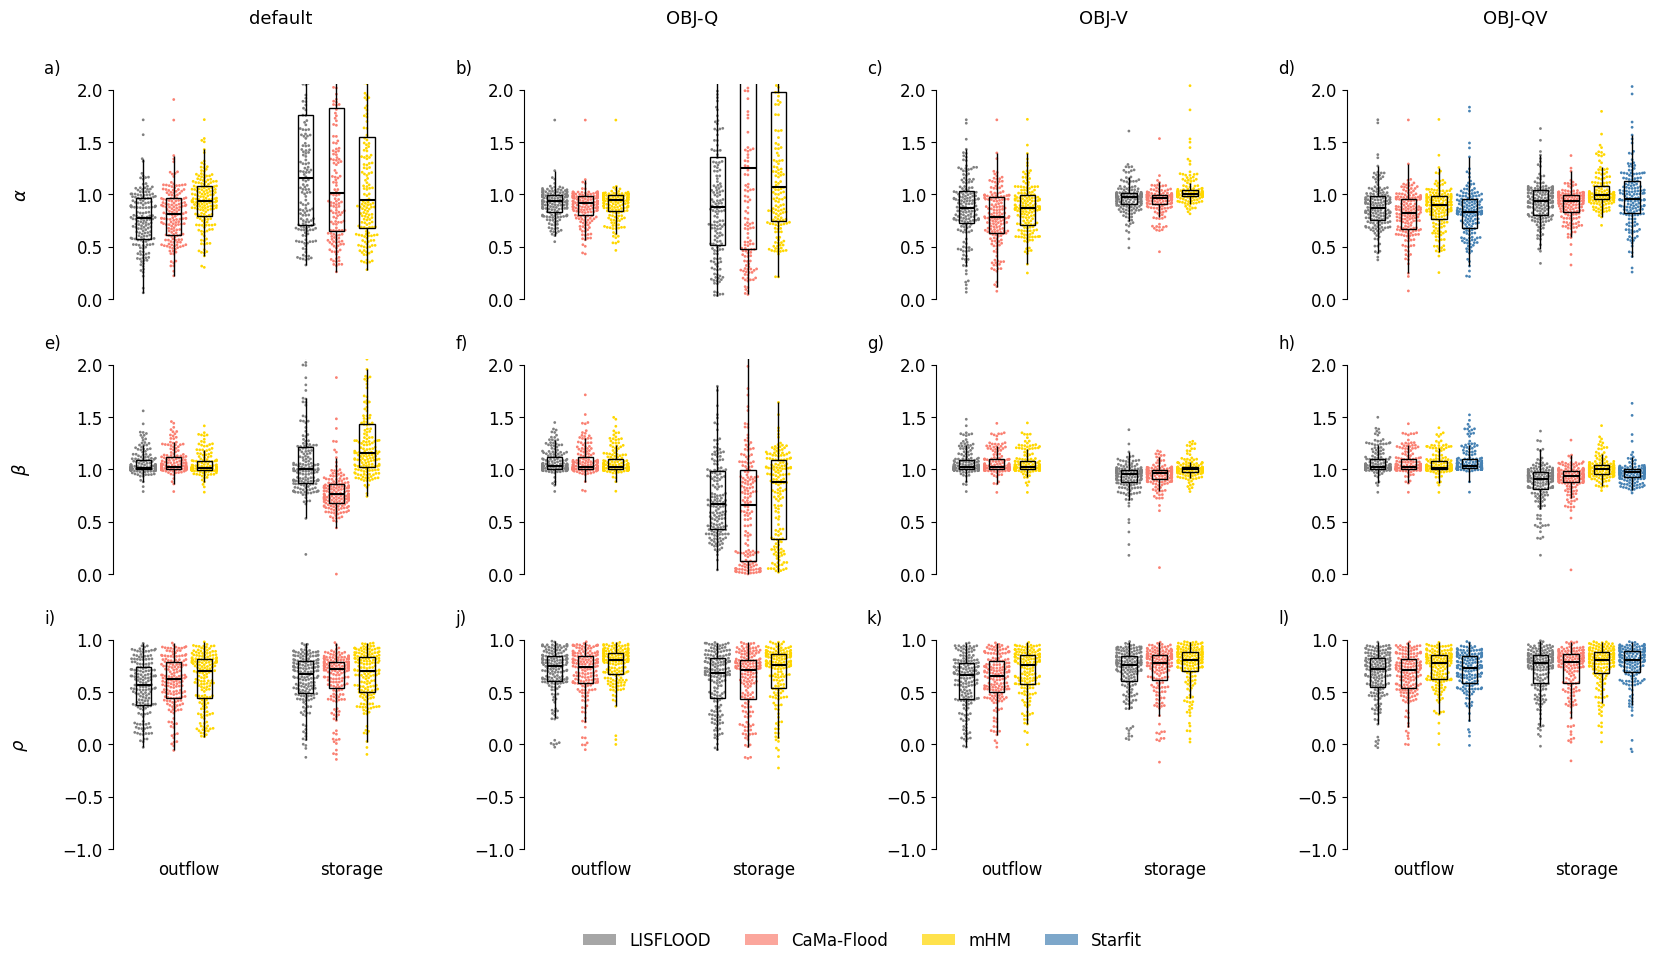

In [12]:
swarmplot_components(
    ds,
    col_dim='run',
    box_dim='model',
    kind='swarm',
    xlim=(-1, 4),
    save=PATH_PLOTS / f'swarmplots_compare_models_components.pdf',
)

### Compare variables

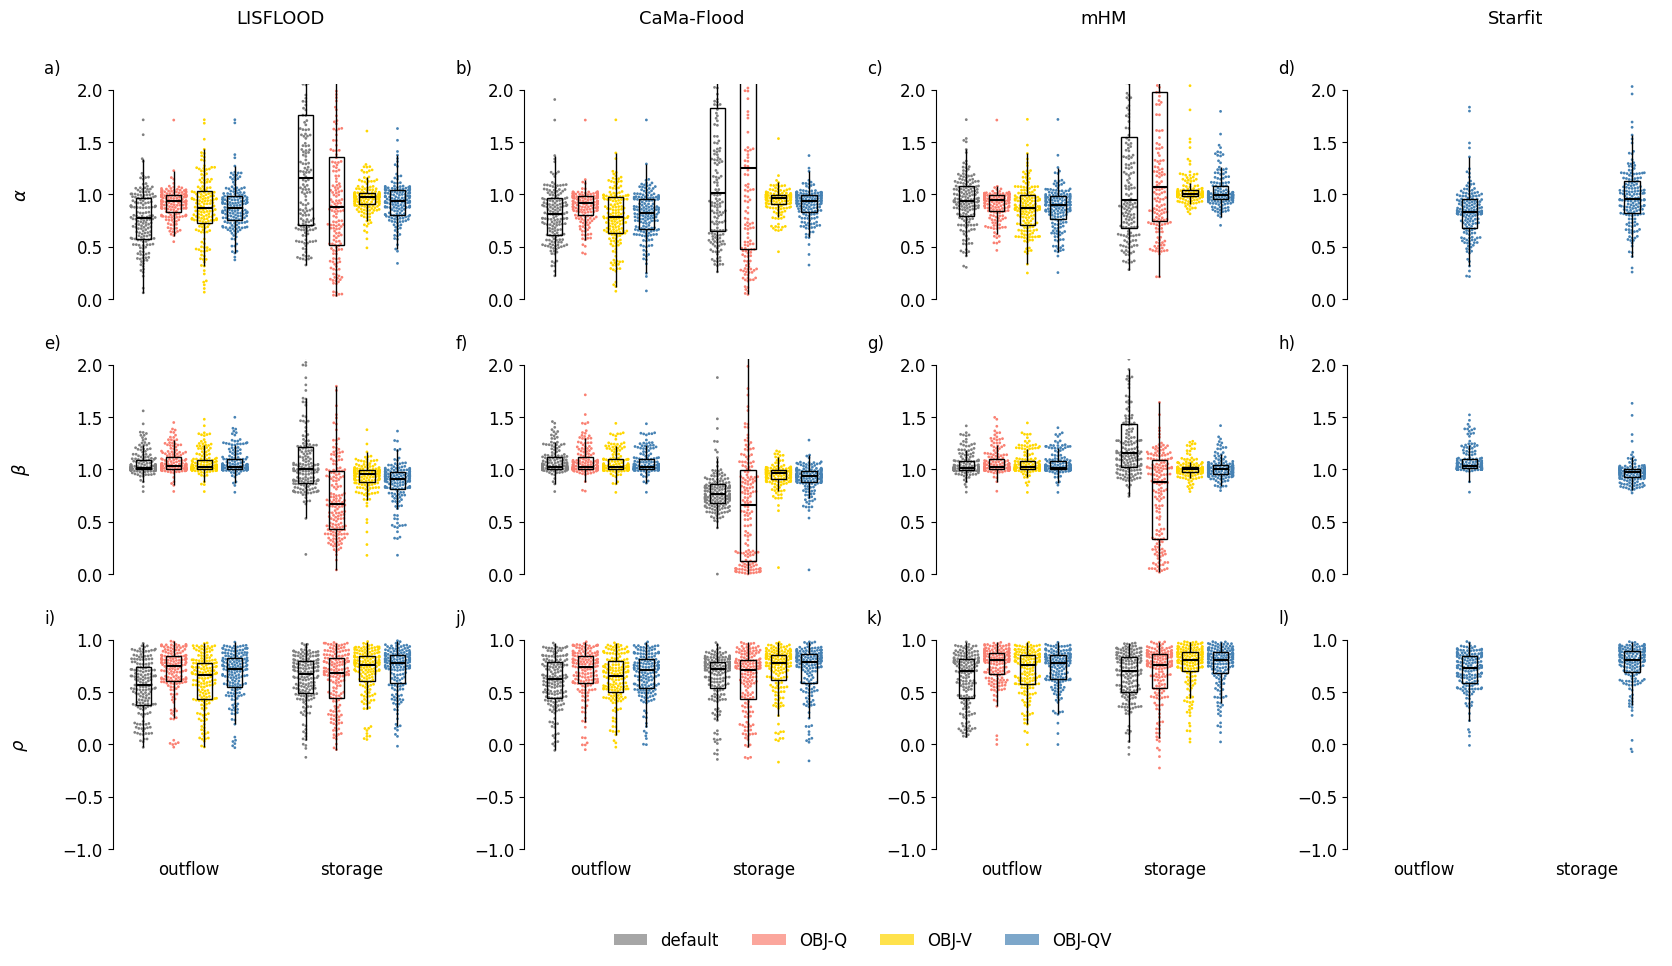

In [13]:
swarmplot_components(
    ds,
    col_dim='model',
    box_dim='run',
    kind='swarm',
    xlim=(-1, 4),
    save=PATH_RESULTS / f'swarmplots_compare_variables_components.pdf',
)

## Appendix C: Performance by reservoir main use

In [ ]:
# extract performance
perf = performance.sel(metric='KGE', run='OBJ-QV').copy()
perf = perf.drop_vars('inflow')

# add 'use' as coordinate
perf.coords['use'] = ('ID', perf.ID.to_series().map(attributes.MAIN_USE))

# compute bivariate performance
var = 'outflow &\nstorage'
perf[var] = perf[var] = 1 - ((1 - perf['outflow'])**2 + (1 - perf['storage'])**2)**.5

# compute median performance by use
perf_use = perf.groupby("use").median()

In [17]:
# performance in terms of storage
perf_use['storage'].to_pandas()

model,LISFLOOD,CaMa-Flood,mHM,Starfit
use,,,,
ELEC,0.7170,0.7510,0.7725,0.6945
FCON,0.6340,0.7385,0.6965,0.7280
IRRI,0.6455,0.6670,0.8170,0.7255
NAVI,0.2405,0.2755,0.3520,0.3315
RECR,0.0030,0.0950,-0.3400,0.4780
SUPP,0.5480,0.7390,0.7320,0.5620


In [18]:
# performance in terms of outflow
perf_use['outflow'].to_pandas()

model,LISFLOOD,CaMa-Flood,mHM,Starfit
use,,,,
ELEC,0.6895,0.6610,0.7200,0.6835
FCON,0.5690,0.5045,0.5605,0.4610
IRRI,0.6380,0.5975,0.7880,0.7550
NAVI,0.8665,0.8605,0.8560,0.8385
RECR,0.6230,0.6040,0.6580,0.5490
SUPP,0.6660,0.6520,0.7100,0.6040


This values were added in Table C1 in the paper.